In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

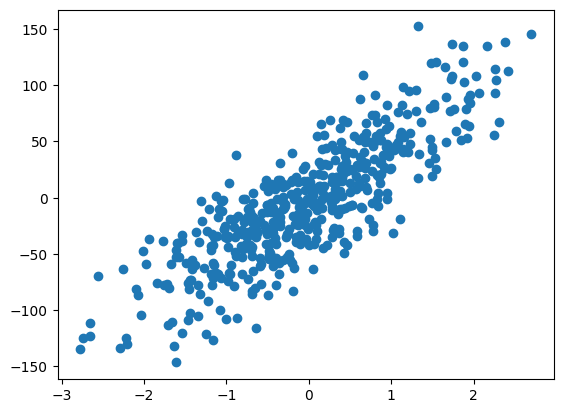

In [92]:
X, y = make_regression(n_samples=500, n_features=1, n_informative=1, n_targets=1, noise=30, random_state=0)
plt.scatter(X, y)

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=0)

# For Simple Linear Regressor

In SLR X and y will be of shape (row, 1)

In [90]:
class MySimpleRidge:

    def __init__(self, alpha=0.01):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X: np.ndarray, y: np.ndarray):
        
        x_mean = X.mean()
        y_mean = y.mean()

        num = 0
        den = 0

        for i in range(X.shape[0]):
            num += ((y[i] - y_mean) * (X[i] - x_mean))
            den += (X[i] - x_mean)**2

        den += self.alpha

        self.coef_ = num/den

        self.intercept_ = y_mean - (self.coef_ * x_mean)

    def predict(self, X_test: np.ndarray) -> np.ndarray:
        return (X_test * self.coef_) + self.intercept_

In [95]:
org_reg = Ridge(alpha = 5)

org_reg.fit(X_train, y_train)

org_reg.coef_, org_reg.intercept_, r2_score(y_test, org_reg.predict(X_test))

(array([43.99882578]), np.float64(-2.4148789303867346), 0.7353512141768296)

In [94]:
my_reg = MySimpleRidge(alpha = 5)

my_reg.fit(X_train, y_train)

my_reg.coef_, my_reg.intercept_, r2_score(y_test, my_reg.predict(X_test))

(array([43.99882578]), array([-2.41487893]), 0.7353512141768296)

# For Multiple Simple Linear Regressor

In MSLR X will be of shape (row, cols)

In [96]:
X, y = make_regression(n_samples=500, n_features=2, n_informative=2, n_targets=1, noise= 40, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=0)

In [ ]:
X_train.shape, X_train.T.shape, np.identity(X_train.shape[0]).shape, X_train.T.shape, y_train.shape

((400, 2), (2, 400), (400, 400), (2, 400), (400,))

In [98]:
class MyMultiRidge:

    def __init__(self, alpha=1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X: np.ndarray, y: np.ndarray):
        
        X = np.insert(X, 0, 1, axis = 1) # Added the intercept term
        I = np.identity(X.shape[1]) # shape is (no. of features + 1)

        betas = np.linalg.inv(np.dot(X.T, X) + self.alpha * I).dot(X.T).dot(y)

        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

        print(self.coef_, self.intercept_)

    def predict(self, X_test: np.ndarray) -> np.ndarray:
        return np.dot(X_test, self.coef_) + self.intercept_

In [100]:
org_reg.fit(X_train, y_train)

org_reg.coef_, org_reg.intercept_, r2_score(y_test, org_reg.predict(X_test))

(array([80.55265805, 67.51730363]),
 np.float64(2.2717316732995947),
 0.8804166873216714)

In [101]:
my_multi_reg = MyMultiRidge()

my_multi_reg.fit(X_train, y_train)

my_multi_reg.coef_, my_multi_reg.intercept_, r2_score(y_test, my_multi_reg.predict(X_test))

[81.44774066 68.17619247] 2.3696993793149295


(array([81.44774066, 68.17619247]),
 np.float64(2.3696993793149295),
 0.8803835467793272)

# Using Gradient Descent 

In [231]:
X_train.shape, X_train.T.shape, np.identity(X_train.shape[0]).shape, X_train.T.shape, y_train.shape

((400, 2), (2, 400), (400, 400), (2, 400), (400,))

In [236]:
class My_GD_Ridge:

    def __init__(self, learning_rate, epochs, alpha = 1):

        self.alpha = alpha
        self.learning_rate = learning_rate
        self.coef_ = None
        self.intercept_ = None
        self.epochs = epochs

    def fit(self, X: np.ndarray, y: np.ndarray):

        self.coef_ = np.ones(X.shape[1])
        self.intercept_ = 0
        betas = np.insert(self.coef_, 0, self.intercept_)

        X = np.insert(X, 0, 1, axis = 1)

        for i in range(self.epochs):

            betas_der = np.dot(X.T, X).dot(betas) - np.dot(X.T, y) + self.alpha * betas 
            betas = betas - self.learning_rate * betas_der
        
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

        print(self.coef_, self.intercept_)
    
    def predict(self, X_test: np.ndarray) -> np.ndarray:
        return np.dot(X_test, self.coef_) + self.intercept_

In [230]:
org_GD_ridge = SGDRegressor(penalty='l2', alpha=0.01, max_iter=25)

org_GD_ridge.fit(X_train, y_train)

org_GD_ridge.coef_, org_GD_ridge.intercept_, r2_score(y_test, org_GD_ridge.predict(X_test))

(array([80.77392846, 67.76845972]), array([2.30604452]), 0.8803096030414939)

In [201]:
reg = Ridge(alpha=5, max_iter=2, solver='sparse_cg')

reg.fit(X_train, y_train)

reg.coef_, reg.intercept_, r2_score(y_test, reg.predict(X_test))

(array([80.55265805, 67.51730363]),
 np.float64(2.2717316732995947),
 0.8804166873216716)

In [241]:
my_GD_ridge = My_GD_Ridge(learning_rate=0.001, epochs=20, alpha=0.1)

my_GD_ridge.fit(X_train, y_train), r2_score(y_test, my_GD_ridge.predict(X_test))

[81.63740301 68.32274352] 2.3890157088886252


(None, 0.8803433749989859)